# Task Timing Analysis
Analyse een enkele CSV log: **waiting time**, **processing time** en **total time** per taak,
plus een overzicht gegroepeerd per case.

In [1]:
# ── Configuration ──────────────────────────────────────────────────────
LOG_FILE = "../../results/runs/cvs/regular/20260301_130635/baseline_random_collab/logs/train/log_train_ep0_20260301_130643.csv"

# Set to True to only count Mon-Fri 08:00-20:00 working hours
USE_WORKING_TIME = True

In [2]:
import sys, os, re
import pandas as pd
import numpy as np

# Add src to path for work_schedule import
sys.path.insert(0, os.path.abspath("../../src"))

if USE_WORKING_TIME:
    from environment.work_schedule import working_seconds_between

# ── Timestamp parsing (handles mixed-precision nanoseconds) ──────────
def safe_parse_timestamps(series: pd.Series) -> pd.Series:
    """Parse timestamps that may have mixed precision (0, 6, or 9 decimal places)."""
    def normalize(ts_str):
        if not isinstance(ts_str, str):
            return ts_str
        # Truncate nanoseconds to microseconds (keep max 6 decimal places)
        ts_str = re.sub(r'(\d{2}:\d{2}:\d{2}\.\d{6})\d+', r'\1', ts_str)
        # Add .000000 to timestamps without fractional seconds
        ts_str = re.sub(r'(\d{2}:\d{2}:\d{2})([+-])', r'\1.000000\2', ts_str)
        return ts_str
    return pd.to_datetime(series.map(normalize), utc=True)

# ── Load data ───────────────────────────────────────────────────────────
df = pd.read_csv(LOG_FILE)
print(f"Loaded {len(df)} tasks from {os.path.basename(LOG_FILE)}")

for col in ["task_assigned_time", "task_started_time", "task_completed_time"]:
    df[col] = safe_parse_timestamps(df[col])

print(f"Cases: {df['case_id'].nunique()}, Tasks: {len(df)}, Agents: {df['task_agent_id'].nunique()}")

Loaded 67963 tasks from log_train_ep0_20260301_130643.csv
Cases: 8192, Tasks: 67963, Agents: 14


In [3]:
# ── Per-task timing ────────────────────────────────────────────────────

def calc_seconds(row, start_col, end_col):
    """Calculate seconds between two timestamps, optionally using working time only."""
    start, end = row[start_col], row[end_col]
    if pd.isna(start) or pd.isna(end):
        return np.nan
    if USE_WORKING_TIME:
        return working_seconds_between(start, end)
    return (end - start).total_seconds()

df["waiting_sec"] = df.apply(calc_seconds, axis=1,
                              start_col="task_assigned_time", end_col="task_started_time")
df["processing_sec"] = df.apply(calc_seconds, axis=1,
                                 start_col="task_started_time", end_col="task_completed_time")
df["total_sec"] = df.apply(calc_seconds, axis=1,
                            start_col="task_assigned_time", end_col="task_completed_time")

# Convert to minutes for readability
df["waiting_min"] = df["waiting_sec"] / 60
df["processing_min"] = df["processing_sec"] / 60
df["total_min"] = df["total_sec"] / 60

print(f"Timing computed for {df['waiting_min'].notna().sum()} / {len(df)} tasks")
print(f"Working time mode: {'Mon-Fri 08:00-20:00' if USE_WORKING_TIME else 'Calendar time (24/7)'}")

Timing computed for 67963 / 67963 tasks
Working time mode: Mon-Fri 08:00-20:00


In [4]:
# ── Per-task overzicht ─────────────────────────────────────────────────
task_cols = ["case_id", "task_name", "task_agent_name", "task_assignment_type",
             "waiting_min", "processing_min", "total_min"]

print("=" * 100)
print("PER-TASK TIMING (minutes)")
print("=" * 100)
display(df[task_cols].round(2))

# Summary stats per task name
print("\n")
print("=" * 100)
print("GEMIDDELDEN PER TASK TYPE (minutes)")
print("=" * 100)
task_stats = df.groupby("task_name")[["waiting_min", "processing_min", "total_min"]].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)
display(task_stats)

PER-TASK TIMING (minutes)


,case_id,task_name,task_agent_name,task_assignment_type,waiting_min,processing_min,total_min
0,0,Process drop-off,Technician-000003,solo_fallback_random,0.00,1.54,1.54
1,0,Enter prescription details,Technician-000003,solo_volunteer,0.00,2.77,2.77
2,0,Check if refill is allowed,Pharmacy System-000001,solo_volunteer,0.00,0.00,0.00
3,0,Check DUR,Pharmacy System-000001,solo_fallback_random,0.00,0.00,0.00
4,0,Pack the drugs (Production),Technician-000003|Technician-000002,collab_fallback_random,0.00,3.02,3.02
...,...,...,...,...,...,...,...
67958,7775,Check Insurance,Pharmacy System-000001,solo_fallback_random,0.00,0.00,0.00
67959,7775,Resolve insurance issues manually,Technician-000002,solo_volunteer_random,3248.41,1.51,3249.92
67960,7775,Pack the drugs (Production),Technician-000001|Technician-000002,collab_volunteer_all_random,1104.69,3.13,1107.81
67961,7775,Check for Quality Assurance,Pharmacist-000001|Technician-000002,collab_volunteer_partial_random,269.40,1.03,270.43




GEMIDDELDEN PER TASK TYPE (minutes)


waiting_min                             \
                                        count     mean   median      std   
task_name                                                                  
Check DUR                                8184     0.00     0.00     0.00   
Check Insurance                          8184     0.00     0.00     0.00   
Check for Quality Assurance              7620  6442.87  6929.08  2949.22   
Check if refill is allowed               8192     0.00     0.00     0.00   
Contact Doctor about refill               439  6586.39  7556.87  3273.35   
Contact customer /  doctor                 75  7172.22  8650.96  2916.37   
Enter prescription details               8192  5443.51  5723.75  2961.01   
Pack the drugs (Production)              7620  6596.46  7354.18  3129.89   
Pick-up                                  8184  5660.03  5252.24  3040.78   
Process drop-off                         8192  4283.60  4445.06  2460.98   
Resolve DUR manually                     1635  6642.31  7837.08  3240.34   
Resolve insurance issues manually        1446  6592.48  7432.84  3180.14   

                                                    processing_min         \
                                      min       max          count   mean   
task_name                                                                   
Check DUR                            0.00      0.00           8184   0.00   
Check Insurance                      0.00      0.00           8184   0.00   
Check for Quality Assurance          0.00  10278.42           7620   1.09   
Check if refill is allowed           0.00      0.00           8192   0.00   
Contact Doctor about refill          9.81  10249.44            439  16.98   
Contact customer /  doctor         889.26  10200.95             75   8.91   
Enter prescription details           0.00   9808.05           8192   2.65   
Pack the drugs (Production)          0.00  10277.69           7620   3.17   
Pick-up                              0.00  10271.88           8184   2.72   
Process drop-off                     0.00   8436.08           8192   1.58   
Resolve DUR manually                 1.51  10272.92           1635   1.94   
Resolve insurance issues manually   35.17  10280.27           1446   3.86   

                                                              total_min  \
                                  median    std   min     max     count   
task_name                                                                 
Check DUR                           0.00   0.00  0.00    0.00      8184   
Check Insurance                     0.00   0.00  0.00    0.00      8184   
Check for Quality Assurance         0.99   2.48  0.68   61.07      7620   
Check if refill is allowed          0.00   0.00  0.00    0.00      8192   
Contact Doctor about refill        11.68  17.70  0.09  123.88       439   
Contact customer /  doctor          6.52   9.47  0.14   68.07        75   
Enter prescription details          2.47   3.38  1.72   62.87      8192   
Pack the drugs (Production)         2.95   3.69  2.22   63.11      7620   
Pick-up                             2.47   3.98  1.75   62.89      8184   
Process drop-off                    1.48   2.48  1.04   61.64      8192   
Resolve DUR manually                1.31   4.44  0.00   64.90      1635   
Resolve insurance issues manually   2.81   4.33  0.02   70.71      1446   

                                                                                
                                      mean   median      std     min       max  
task_name                                                                       
Check DUR                             0.00     0.00     0.00    0.00      0.00  
Check Insurance                       0.00     0.00     0.00    0.00      0.00  
Check for Quality Assurance        6443.96  6930.10  2949.16    1.01  10279.50  
Check if refill is allowed            0.00     0.00     0.00    0.00      0.00  
Contact Doctor about refill        6603.37  

In [5]:
# ── Per-case overzicht ─────────────────────────────────────────────────
case_agg = df.groupby("case_id").agg(
    n_tasks=("task_name", "count"),
    total_waiting_min=("waiting_min", "sum"),
    total_processing_min=("processing_min", "sum"),
    total_total_min=("total_min", "sum"),
    avg_waiting_min=("waiting_min", "mean"),
    avg_processing_min=("processing_min", "mean"),
    max_waiting_min=("waiting_min", "max"),
    max_processing_min=("processing_min", "max"),
).round(2)

# Case throughput = case_completed - case_open (overall)
case_times = df.groupby("case_id").agg(
    case_open=("task_assigned_time", "min"),
    case_close=("task_completed_time", "max"),
)
if USE_WORKING_TIME:
    case_agg["case_throughput_min"] = case_times.apply(
        lambda r: working_seconds_between(r["case_open"], r["case_close"]) / 60, axis=1
    ).round(2)
else:
    case_agg["case_throughput_min"] = (
        (case_times["case_close"] - case_times["case_open"]).dt.total_seconds() / 60
    ).round(2)

print("=" * 100)
print("PER-CASE TOTALEN (minutes)")
print("=" * 100)
display(case_agg)

# Summary
print("\n")
print("=" * 100)
print("SAMENVATTING OVER ALLE CASES")
print("=" * 100)
summary = case_agg.describe().round(2)
display(summary)

PER-CASE TOTALEN (minutes)


,n_tasks,total_waiting_min,total_processing_min,total_total_min,avg_waiting_min,avg_processing_min,max_waiting_min,max_processing_min,case_throughput_min
case_id,,,,,,,,,
0,8,0.00,11.22,11.22,0.00,1.40,0.00,3.02,11.22
1,9,24.47,13.79,38.26,2.72,1.53,9.39,3.29,38.26
2,8,29.45,10.44,39.89,3.68,1.31,9.39,2.94,39.89
3,9,86.60,11.37,97.97,9.62,1.26,42.17,2.84,97.97
4,7,11.82,8.94,20.76,1.69,1.28,8.01,2.77,20.76
...,...,...,...,...,...,...,...,...,...
8187,9,36777.26,10.80,36788.06,4086.36,1.20,10039.85,3.03,36788.06
8188,9,36759.84,13.56,36773.40,4084.43,1.51,10038.94,3.01,36773.40
8189,8,36010.07,9.96,36020.03,4501.26,1.24,10043.72,2.95,36020.03




SAMENVATTING OVER ALLE CASES


,n_tasks,total_waiting_min,total_processing_min,total_total_min,avg_waiting_min,avg_processing_min,max_waiting_min,max_processing_min,case_throughput_min
count,8192.0,8192.00,8192.00,8192.00,8192.00,8192.00,8192.00,8192.00,8192.00
mean,8.3,30418.47,12.97,30431.44,3648.58,1.55,8145.83,4.96,30431.44
std,0.8,12927.20,9.76,12928.04,1491.92,1.12,2940.76,8.99,12928.04
min,4.0,0.00,5.08,11.22,0.00,0.83,0.00,2.04,11.22
25%,8.0,21091.41,10.16,21102.38,2639.70,1.25,7019.15,2.84,21102.38
50%,8.0,36768.21,10.57,36779.23,4378.57,1.30,9864.90,2.98,36779.23
75%,9.0,39670.89,11.90,39682.14,4830.61,1.36,10075.44,3.16,39682.14
max,11.0,51271.37,141.09,51319.39,6974.39,16.35,10280.27,123.88,51319.39


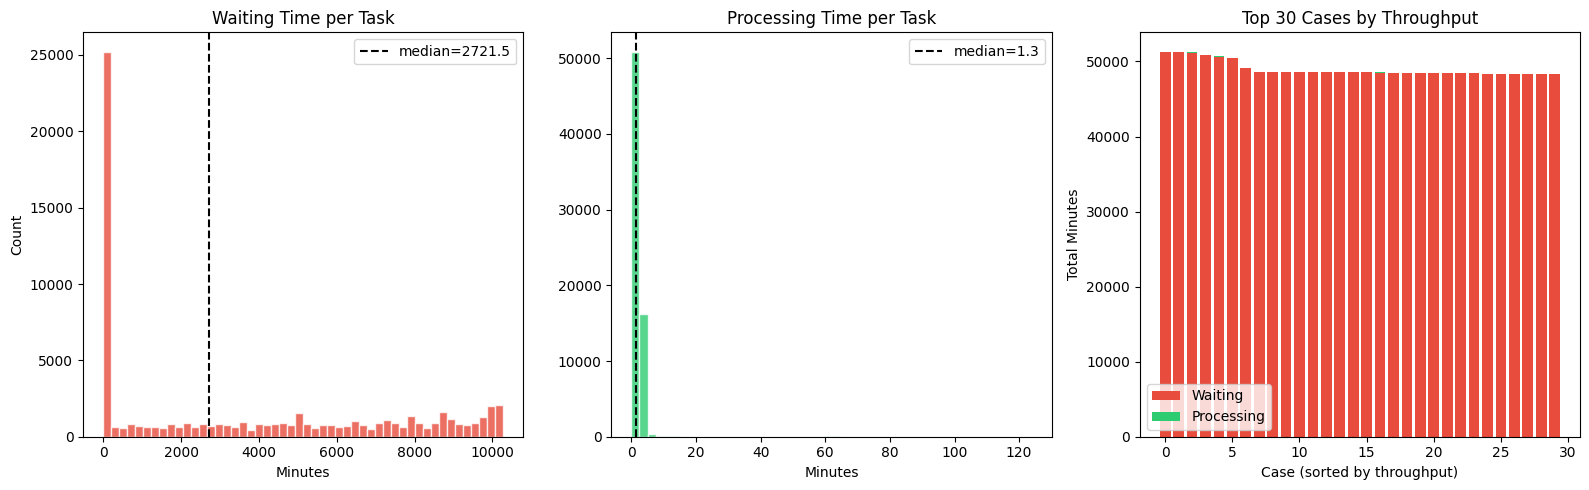

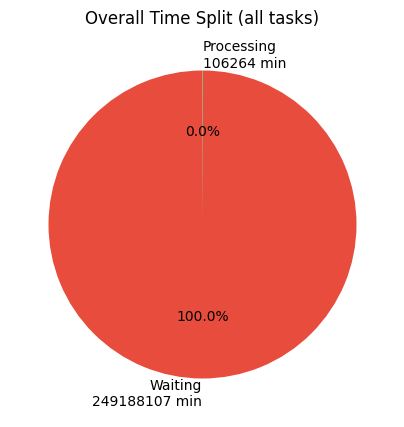

In [6]:
# ── Visueel: verdeling waiting vs processing ──────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Histogram waiting time
axes[0].hist(df["waiting_min"].dropna(), bins=50, color="#e74c3c", alpha=0.8, edgecolor="white")
axes[0].set_title("Waiting Time per Task")
axes[0].set_xlabel("Minutes")
axes[0].set_ylabel("Count")
axes[0].axvline(df["waiting_min"].median(), color="black", ls="--", label=f"median={df['waiting_min'].median():.1f}")
axes[0].legend()

# 2. Histogram processing time
axes[1].hist(df["processing_min"].dropna(), bins=50, color="#2ecc71", alpha=0.8, edgecolor="white")
axes[1].set_title("Processing Time per Task")
axes[1].set_xlabel("Minutes")
axes[1].axvline(df["processing_min"].median(), color="black", ls="--", label=f"median={df['processing_min'].median():.1f}")
axes[1].legend()

# 3. Per-case: stacked bar totals
top_n = min(30, len(case_agg))
top_cases = case_agg.nlargest(top_n, "case_throughput_min")
x = range(len(top_cases))
axes[2].bar(x, top_cases["total_waiting_min"], color="#e74c3c", label="Waiting")
axes[2].bar(x, top_cases["total_processing_min"], bottom=top_cases["total_waiting_min"],
            color="#2ecc71", label="Processing")
axes[2].set_title(f"Top {top_n} Cases by Throughput")
axes[2].set_xlabel("Case (sorted by throughput)")
axes[2].set_ylabel("Total Minutes")
axes[2].legend()

plt.tight_layout()
plt.show()

# Pie chart: overall time split
total_waiting = df["waiting_min"].sum()
total_processing = df["processing_min"].sum()
fig2, ax2 = plt.subplots(figsize=(5, 5))
ax2.pie([total_waiting, total_processing],
        labels=[f"Waiting\n{total_waiting:.0f} min", f"Processing\n{total_processing:.0f} min"],
        colors=["#e74c3c", "#2ecc71"], autopct="%1.1f%%", startangle=90)
ax2.set_title("Overall Time Split (all tasks)")
plt.show()